# Feature extraction: SPOC scores and avg_n_models scores histograms of RNase and L1KD experimental dataset analysis


In [1]:
import seaborn as sns
sns.set_theme(style="darkgrid", context="paper")
from scipy.stats import mannwhitneyu


## A) RNase

1. Load SPOC summary table

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid", context="paper")
from scipy.stats import mannwhitneyu

# Paths to SPOC_summary.csv files
path_pos = "/mnt/storage/ana01/results/SPOC_afm_10_RNase_22/SPOC_summary_positive.csv"
path_neg = "/mnt/storage/ana01/results/SPOC_afm_11_RNase_13_no_MOV10_wTRA2A/SPOC_summary_negative.csv"

# Load and extract only the needed columns
def load_spoc_data(path):
    df = pd.read_csv(path, usecols=["spoc_score", "avg_n_models", "biogrid_detect_count"])
    return df.dropna()

df_pos = load_spoc_data(path_pos)
df_neg = load_spoc_data(path_neg)


# Print some quick descriptive stats (optional)
print("Basic Summary")
print("Positive group:\n", df_pos[["spoc_score", "avg_n_models"]].describe(), "\n")
print("Negative group:\n", df_neg[["spoc_score", "avg_n_models"]].describe(), "\n")


2. Histogram of SPOC scores (Figire 8)

In [ ]:
# Mann–Whitney U test
from scipy.stats import mannwhitneyu

U_stat, p_value = mannwhitneyu(
    df_pos["spoc_score"],
    df_neg["spoc_score"],
    alternative="greater"
)

# Histogram

import numpy as np

bins = np.arange(0, 1.05, 0.025)

colors = sns.color_palette("deep")

plt.figure(figsize=(10, 5))

sns.histplot(
    df_pos["spoc_score"],
    stat="density",
    fill=True,
    color=colors[0],
    label="RNA-independent Complexes (22)",
    alpha=0.7,
    bins=bins
)

sns.histplot(
    df_neg["spoc_score"],
    stat="density",
    fill=True,
    color=colors[1],
    label="RNA-dependent Complexes (13)",
    alpha=0.6,
    bins=bins
)

title = f"MWU Test: Statistic = {U_stat:.2f}, p-value = {p_value:.2e}"
title = title.replace(".", ",")

plt.title(title, fontsize=20)
plt.axvline(x=0.5, color="red", linestyle="--", linewidth=1)
plt.xlabel("SPOC score", fontsize=20)
plt.ylabel("Density", fontsize=20)


ticks = np.arange(0, 1.0, 0.1)
labels = ["0" if x == 0 else f"{x:.1f}".replace(".", ",") for x in ticks]
plt.xticks(ticks, labels, fontsize=18)
plt.yticks(fontsize=18)

plt.legend(fontsize=18)
plt.xlim(-0.025, 0.55)
plt.tight_layout()

plt.savefig(
    "/mnt/storage/ana01/results/thesis_figures/spoc_score_RNase_mwu.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


* H₀: SPOC Scores of RNA-independent binders are not greater than those of RNA-dependent binders.
* H₁: SPOC Scores of RNA-independent binders are greater than those of RNA-dependent binders.

COMMENT: U = 138, which lies roughly in the middle between the minimum (0) and maximum (n₁ × n₂ = 22 × 12 = 264). This suggests no strong dominance of one group over the other in SPOC scores.

p-value = 0.399, which is greater than 0.05, indicating no statistically significant evidence that the positive class has higher SPOC scores than the negative class.

Conclusion: H0 is confirmed.

3. Histogram of avg_n_models (Figure 9)

In [ ]:
# Mann–Whitney U test
from scipy.stats import mannwhitneyu

U_stat, p_value = mannwhitneyu(
    df_pos["avg_n_models"],
    df_neg["avg_n_models"],
    alternative="greater"
)

import numpy as np

all_vals = np.concatenate([df_pos["avg_n_models"], df_neg["avg_n_models"]])

bin_width = 0.05
bins = np.arange(
    np.floor(all_vals.min() / bin_width) * bin_width,
    np.ceil(all_vals.max() / bin_width) * bin_width + bin_width,
    bin_width
)

plt.figure(figsize=(10, 5))

sns.histplot(
    df_pos["avg_n_models"],
    stat="density",
    fill=True,
    color=colors[0],
    label="RNA-independent Complexes (22)",
    alpha=0.7,
    bins=bins
)

sns.histplot(
    df_neg["avg_n_models"],
    stat="density",
    fill=True,
    color=colors[1],
    label="RNA-dependent Complexes (13)",
    alpha=0.6,
    bins=bins
)

title = f"MWU Test: Statistic = {U_stat:.2f}, p-value = {p_value:.2e}".replace(".", ",")
plt.title(title, fontsize=20)

plt.xlabel("avg_n_models", fontsize=20)
plt.ylabel("Density", fontsize=20)

ticks = np.arange(
    np.floor(all_vals.min() / 0.1) * 0.1,
    np.ceil(all_vals.max() / 0.1) * 0.1 + 0.1,
    0.1
)

tick_labels = ["0" if abs(x) < 1e-9 else f"{x:.1f}".replace(".", ",") for x in ticks]

plt.xticks(ticks, tick_labels, fontsize=18)
plt.yticks(fontsize=18)

plt.axvline(0.5, color="red", linestyle="--", linewidth=1)

plt.legend(fontsize=18)

plt.tight_layout()

plt.savefig(
    "/mnt/storage/ana01/results/thesis_figures/avg_n_models_RNase_mwu.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("Mann–Whitney U Test for avg_n_models (one-sided)")
print(f"U statistic: {U_stat:.3f}".replace(".", ","))
print(f"p-value:     {p_value:.3e}".replace(".", ","))

U = 144, which lies roughly in the middle between the minimum (0) and maximum, this suggests no strong dominance of one group over the other in avg_n_models.
p-value = 0.302 is greater than 0.05
H0 is confirmed.


## B) L1KD

1. Comparison between SPOC score and Avg models score distribution in significant FC positive and FC negative protein L1KD dataset protein groups.

* INPUTS: 2 SPOC summary tables (CSV)
* OUTPUTS: plots of SPOC score distributions and Avg models score distribution

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Paths to SPOC_summary.csv files
path_pos = "/mnt/storage/ana01/results/SPOC_FCpos_no_CLK2/SPOC_summary_positive.csv"
path_neg = "/mnt/storage/ana01/results/SPOC_FCneg_no_MACF1_no_ABCG2/SPOC_summary_negative.csv"

# Load and extract only the needed columns
def load_spoc_data(path):
    df = pd.read_csv(path, usecols=["spoc_score", "avg_n_models", "biogrid_detect_count"])
    return df.dropna()

df_pos = load_spoc_data(path_pos)
df_neg = load_spoc_data(path_neg)


# Print some quick descriptive stats (optional)
print("Basic Summary")
print("FC Positive group:\n", df_pos[["spoc_score", "avg_n_models"]].describe(), "\n")
print("FC Negative group:\n", df_neg[["spoc_score", "avg_n_models"]].describe(), "\n")


Basic Summary
FC Positive group:
        spoc_score  avg_n_models
count   55.000000     55.000000
mean     0.012945      0.069545
std      0.029704      0.155168
min      0.000000      0.000000
25%      0.000000      0.000000
50%      0.000000      0.000000
75%      0.000000      0.000000
max      0.093000      0.631000 

FC Negative group:
        spoc_score  avg_n_models
count   87.000000     87.000000
mean     0.011195      0.055529
std      0.028496      0.138262
min      0.000000      0.000000
25%      0.000000      0.000000
50%      0.000000      0.000000
75%      0.000000      0.000000
max      0.114000      0.656000 



2. Histogram of SPOC score distributions (Figure A5)

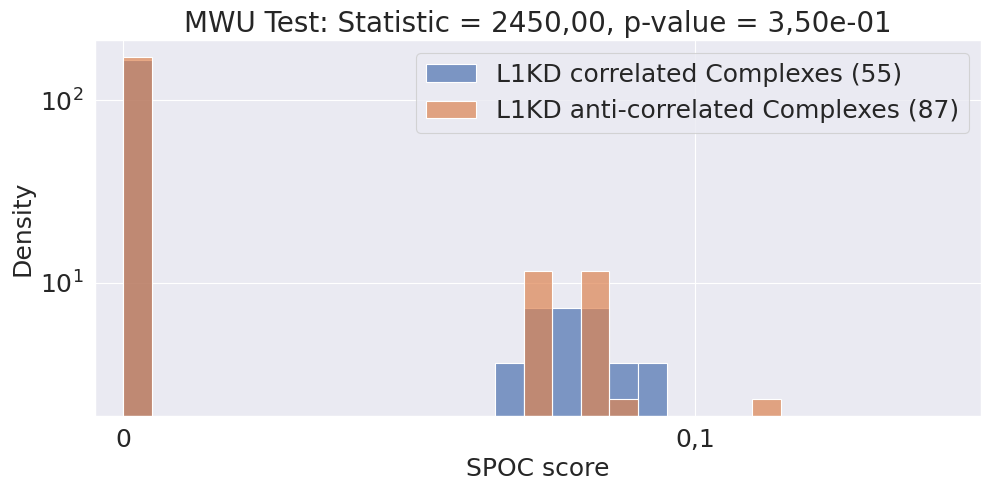

In [3]:
# Mann–Whitney U test
from scipy.stats import mannwhitneyu
import numpy as np

U_stat, p_value = mannwhitneyu(
    df_pos["spoc_score"],
    df_neg["spoc_score"],
    alternative="greater"
)

all_vals = np.concatenate([df_pos["spoc_score"], df_neg["spoc_score"]])

bin_width = 0.005
min_edge = np.floor(all_vals.min() / bin_width) * bin_width
max_edge = np.ceil(all_vals.max() / bin_width) * bin_width
bins = np.arange(min_edge, max_edge + bin_width, bin_width)

colors = sns.color_palette("deep")

plt.figure(figsize=(10, 5))

sns.histplot(
    df_pos["spoc_score"],
    stat="density",
    fill=True,
    color=colors[0],
    label="L1KD correlated Complexes (55)",
    alpha=0.7,
    bins=bins
)

sns.histplot(
    df_neg["spoc_score"],
    stat="density",
    fill=True,
    color=colors[1],
    label="L1KD anti-correlated Complexes (87)",
    alpha=0.7,
    bins=bins
)

title = f"MWU Test: Statistic = {U_stat:.2f}, p-value = {p_value:.2e}"
title = title.replace(".", ",")

plt.title(title, fontsize=20)
plt.xlabel("SPOC score", fontsize=18)
plt.ylabel("Density", fontsize=18)

ticks = np.arange(
    np.floor(all_vals.min() / 0.1) * 0.1,
    np.ceil(all_vals.max() / 0.1) * 0.1 + 0.1,
    0.1
)

labels = [
    "0" if abs(x) < 1e-9 else f"{x:.1f}".replace(".", ",")
    for x in ticks
]

plt.xticks(ticks, labels, fontsize=18)
plt.yticks(fontsize=18)

plt.yscale("log")
plt.xlim(-0.005, 0.150)
plt.legend(fontsize=18)

plt.tight_layout()
plt.show()
plt.close()


* H₀: L1KD correlated scores are not greater than L1KD anti-correlated
* H₁: L1KD correlated scores are greater than L1KD anti-correlated


U = 2450, which is roughly in the middle between max (n1*n2=4785) and min (0) → suggests no strong dominance of one group over the other.
p-value 0.3495 is higher than 0.05, so there is no statistically significant difference.


Conclusion: H0 is confirmed

3. Histogram of avg_n_models (Figure A6)

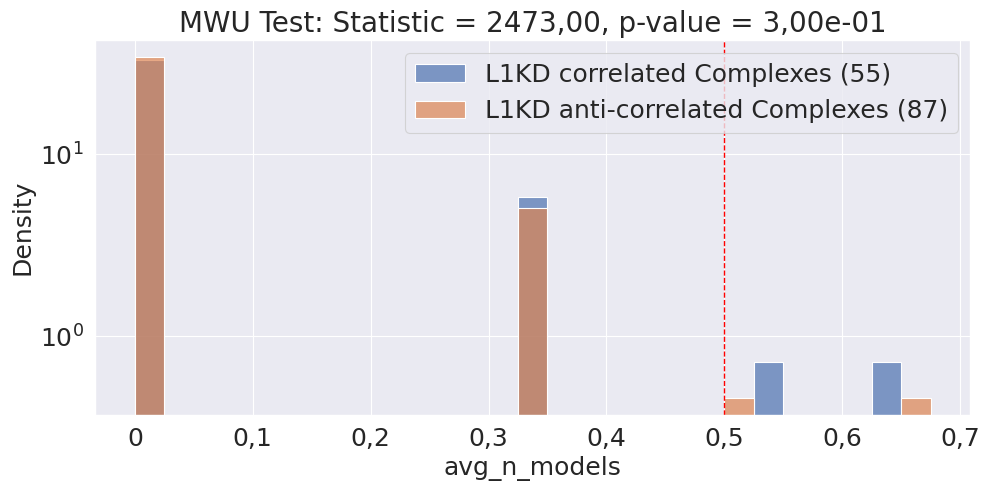

Mann–Whitney U Test for avg_n_models (one-sided)
U statistic: 2473,000
p-value:     3,002e-01


In [4]:
# Mann–Whitney U test
from scipy.stats import mannwhitneyu
import numpy as np

U_stat, p_value = mannwhitneyu(
    df_pos["avg_n_models"],
    df_neg["avg_n_models"],
    alternative="greater"
)

all_vals = np.concatenate([df_pos["avg_n_models"], df_neg["avg_n_models"]])

bin_width = 0.025
min_edge = np.floor(all_vals.min() / bin_width) * bin_width
max_edge = np.ceil(all_vals.max() / bin_width) * bin_width
bins = np.arange(min_edge, max_edge + bin_width, bin_width)

plt.figure(figsize=(10, 5))

sns.histplot(
    df_pos["avg_n_models"],
    stat="density",
    fill=True,
    color=colors[0],
    label="L1KD correlated Complexes (55)",
    alpha=0.7,
    bins=bins
)

sns.histplot(
    df_neg["avg_n_models"],
    stat="density",
    fill=True,
    color=colors[1],
    label="L1KD anti-correlated Complexes (87)",
    alpha=0.7,
    bins=bins
)

title = f"MWU Test: Statistic = {U_stat:.2f}, p-value = {p_value:.2e}"
title = title.replace(".", ",")

plt.title(title, fontsize=20)
plt.xlabel("avg_n_models", fontsize=18)
plt.ylabel("Density", fontsize=18)

ticks = np.arange(
    np.floor(all_vals.min() / 0.1) * 0.1,
    np.ceil(all_vals.max() / 0.1) * 0.1 + 0.1,
    0.1
)

labels = [
    "0" if abs(x) < 1e-9 else f"{x:.1f}".replace(".", ",")
    for x in ticks
]
plt.xticks(ticks, labels, fontsize=18)
plt.yticks(fontsize=18)

plt.yscale("log")

plt.axvline(x=0.5, color="red", linestyle="--", linewidth=1)

plt.legend(fontsize=18)

plt.tight_layout()
plt.show()
plt.close()

print("Mann–Whitney U Test for avg_n_models (one-sided)")
print(f"U statistic: {U_stat:.3f}".replace(".", ","))
print(f"p-value:     {p_value:.3e}".replace(".", ","))

NOTEBOOK CONCLUSION: Not the SPOC score nor avg_n_models score were able to distinguish functional from spurious interactions of both experimental datasets.